In [3]:
import pandas as pd

df = pd.read_csv('/content/healthcare_data_cleaning_dataset.csv')

###Q1. Missing Data Identification


Identify missing values in each column of the dataset and calculate the percentage of missing data.

###Explanation

Missing data refers to the absence of values in a dataset. In real-world datasets like healthcare, missing values can occur due to:

Human error during data entry
System failures
Incomplete patient records

If missing values are not handled properly, they can lead to:

Incorrect analysis
Biased results
Poor decision-making

To analyze missing data:

We first identify how many values are missing in each column using isnull()
Then we calculate the percentage using formula:
(Missing Values / Total Records) × 100

This helps in understanding how severe the missing data problem is.

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Count missing values
missing_values = df.isnull().sum()

# Calculate percentage
missing_percentage = (missing_values / len(df)) * 100

# Display results
print("Missing Values:\n", missing_values)
print("\nMissing Percentage:\n", missing_percentage)

Missing Values:
 Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

Missing Percentage:
 Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


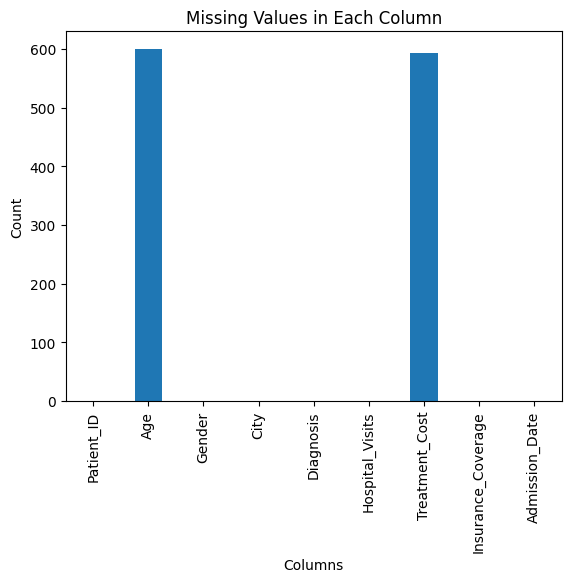

In [17]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()

plt.figure()
missing_values.plot(kind='bar')
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

###Output Explanation

The output shows:

Total number of missing values in each column
Percentage of missing values

Columns with higher missing percentage require more attention and proper handling.

###Q2. Handling Missing Age


Replace missing Age values using an appropriate method and justify your choice (mean/median).

###Detailed Explanation

Age is an important variable in a healthcare dataset because it plays a crucial role in diagnosis, treatment planning, and medical analysis. However, due to incomplete records or data entry errors, some Age values may be missing.

Missing Age values need to be handled carefully to maintain the accuracy and reliability of the dataset.

There are two common methods to handle missing numerical values:

Mean (Average)
Median (Middle Value)

In this case, median is preferred over mean because:

Age data may contain extreme values (outliers)
Mean gets affected by outliers and may give misleading results
Median is more robust and represents the central tendency better

Therefore, replacing missing Age values with the median value ensures that the dataset remains balanced and realistic.

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Check missing values before
print("Missing values before handling:")
print(df['Age'].isnull().sum())

# Step 2: Calculate median
median_age = df['Age'].median()
print("\nCalculated Median Age:", median_age)

# Step 3: Fill missing values with median
df['Age'] = df['Age'].fillna(median_age)

# Step 4: Check missing values after
print("\nMissing values after handling:")
print(df['Age'].isnull().sum())

# Step 5: Show updated data
print("\nUpdated Age Column:")
print(df['Age'].head())

Missing values before handling:
600

Calculated Median Age: 50.0

Missing values after handling:
0

Updated Age Column:
0    35.0
1    21.0
2    77.0
3    79.0
4    60.0
Name: Age, dtype: float64


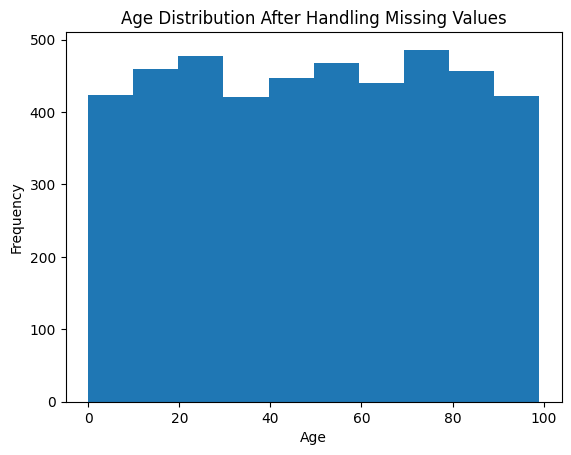

In [18]:
plt.figure()
plt.hist(df['Age'])
plt.title("Age Distribution After Handling Missing Values")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

###Output Explanation

After applying the above code:

All missing values in the Age column are replaced with the median value
The count of missing values becomes zero
The dataset becomes more complete and suitable for analysis
###Conclution

“Median is used instead of mean because age data may contain outliers. Median is not affected by extreme values and provides a more accurate central value. Therefore, missing Age values are replaced using the median method.”

###Q3. Handling Missing Treatment Cost


Handle missing Treatment_Cost values. Choose the correct imputation method and explain why.

###Detailed Explanation

Treatment cost is an important numerical variable in a healthcare dataset. However, it is usually highly skewed because:

Some treatments are very expensive
Most treatments have moderate or low cost

Due to this skewness:

Mean is affected by extreme values (outliers)
It may give an incorrect average

 Therefore, median is the most appropriate method because:

It is not affected by outliers
It represents the central tendency accurately
It gives a realistic estimate of treatment cost

Thus, missing Treatment_Cost values are replaced using the median method.

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Check missing values before
print("Missing values before handling:")
print(df['Treatment_Cost'].isnull().sum())

# Step 2: Calculate median
median_cost = df['Treatment_Cost'].median()
print("\nCalculated Median Treatment Cost:", median_cost)

# Step 3: Fill missing values
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(median_cost)

# Step 4: Check missing values after
print("\nMissing values after handling:")
print(df['Treatment_Cost'].isnull().sum())

# Step 5: Show updated data
print("\nUpdated Treatment Cost Column:")
print(df['Treatment_Cost'].head())

Missing values before handling:
593

Calculated Median Treatment Cost: 24797.0

Missing values after handling:
0

Updated Treatment Cost Column:
0    41010.0
1    12194.0
2    45086.0
3    40842.0
4     9873.0
Name: Treatment_Cost, dtype: float64


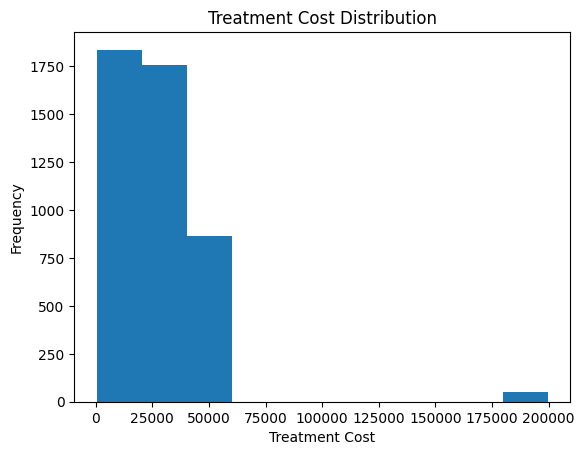

In [19]:
plt.figure()
plt.hist(df['Treatment_Cost'])
plt.title("Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()

###Output Explanation
The number of missing values before handling is displayed
The median treatment cost is calculated
Missing values are replaced using the median
After replacement, missing values become zero
Updated column values are displayed
###conclution

 “Median is used instead of mean because treatment cost data is highly skewed. Mean is affected by extreme values, whereas median provides a more reliable and robust estimate. Therefore, median imputation is the most suitable method.”

###Q4. Duplicate Patient Records


Identify duplicate rows, remove duplicates, and compare dataset size before and after.

###Detailed Explanation

Duplicate records occur when the same data is entered more than once in the dataset. In a healthcare dataset, duplicates may arise due to:

Manual data entry errors
System glitches
Multiple entries for the same patient

Duplicate data can cause several problems:

Increases dataset size unnecessarily
Leads to incorrect analysis and biased results
Affects accuracy of statistical calculations

To handle duplicate records, the following steps are performed:

Identify duplicate rows using duplicated() function
Count the number of duplicate records
Remove duplicate rows using drop_duplicates()
Compare dataset size before and after removal

This ensures that the dataset contains only unique and accurate records.

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Dataset size before
before_rows = df.shape[0]
print("Dataset size before removing duplicates:", before_rows)

# Step 2: Identify duplicate rows
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# Step 3: Remove duplicates
df = df.drop_duplicates()

# Step 4: Dataset size after
after_rows = df.shape[0]
print("\nDataset size after removing duplicates:", after_rows)

# Step 5: Rows removed
print("\nNumber of rows removed:", before_rows - after_rows)

Dataset size before removing duplicates: 5100

Number of duplicate rows: 99

Dataset size after removing duplicates: 5001

Number of rows removed: 99


###Output Explanation
The dataset size before removing duplicates is displayed
Total number of duplicate rows is identified
Duplicate rows are removed
The dataset size after cleaning is shown
The number of removed rows is calculated
###Conclusion

 “Duplicate records were successfully identified and removed from the dataset. This ensures data accuracy, reduces redundancy, and improves the reliability of analysis.”

###Q5. Invalid Age Values (Data Quality Check)


Detect unrealistic age values (e.g., >100 or <0) and decide whether to remove or correct them.

###Detailed Explanation

Invalid data refers to values that are logically incorrect or unrealistic. In a healthcare dataset, Age is an important variable and must be accurate.

Examples of invalid age values:

Age < 0 → not possible
Age > 100 → generally unrealistic (in most datasets)

These values may occur due to:

Data entry errors
Typing mistakes
System issues

Such incorrect values can:

Distort analysis
Lead to wrong conclusions
Reduce data quality

There are two ways to handle invalid data:

Correction (if correct value is known)
Removal (if value is unreliable)

 In this case, removal is the best option because:

No correct value is available
Keeping such data will reduce accuracy

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Detect invalid age values
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

print("Invalid Age Records:")
print(invalid_age)

print("\nNumber of invalid records:", len(invalid_age))

# Step 2: Remove invalid values
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# Step 3: Verify removal
print("\nDataset size after removing invalid age values:", df.shape[0])

Invalid Age Records:
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []

Number of invalid records: 0

Dataset size after removing invalid age values: 4500


###Output Explanation
All records with invalid age values are identified
Total number of invalid records is displayed
These records are removed from the dataset
Dataset size is updated after cleaning
###Conclusion

“Invalid age values such as negative values and values greater than 100 were identified and removed. This improves the accuracy and reliability of the dataset.”

###Q6. Outlier Detection (Treatment Cost)

Detect outliers in Treatment_Cost using IQR method and display the number of outliers.

###Detailed Explanation

Outliers are extreme values that differ significantly from other observations in the dataset. In a healthcare dataset, treatment cost may contain outliers because:

Some treatments are extremely expensive
Most treatments are of average cost

Outliers can:

Distort statistical analysis
Affect mean and standard deviation
Lead to incorrect conclusions

To detect outliers, we use the IQR (Interquartile Range) method.

🔹 Steps in IQR Method:
Q1 (First Quartile) → 25th percentile
Q3 (Third Quartile) → 75th percentile
IQR = Q3 − Q1
🔹 Outlier Range:
Lower Limit = Q1 − 1.5 × IQR
Upper Limit = Q3 + 1.5 × IQR

 Any value outside this range is considered an outlier.

In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Calculate Q1 and Q3
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# Step 2: Calculate IQR
IQR = Q3 - Q1

# Step 3: Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

# Step 4: Detect outliers
outliers = df[(df['Treatment_Cost'] < lower_limit) |
              (df['Treatment_Cost'] > upper_limit)]

# Step 5: Count outliers
print("\nNumber of Outliers:", len(outliers))

Q1: 12498.0
Q3: 37922.0
IQR: 25424.0
Lower Limit: -25638.0
Upper Limit: 76058.0

Number of Outliers: 50


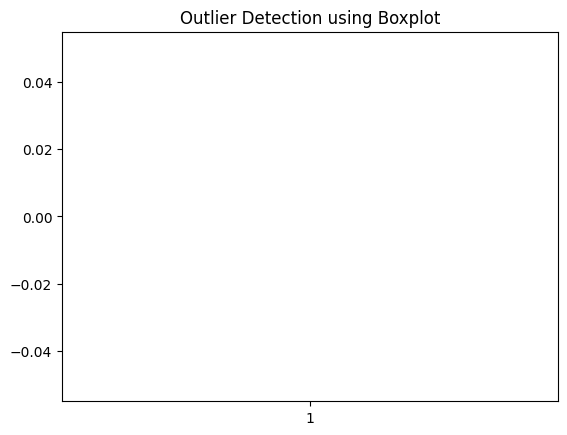

In [20]:
plt.figure()
plt.boxplot(df['Treatment_Cost'])
plt.title("Outlier Detection using Boxplot")
plt.show()

###Output Explanation
Q1 and Q3 values are calculated
IQR is computed
Lower and upper limits are determined
Values outside the range are identified as outliers
Total number of outliers is displayed
###Conclusion

“Outliers in the Treatment_Cost column were detected using the IQR method. These extreme values can affect analysis and should be handled appropriately.”

###Q7. Outlier Treatment (Winsorization)

Apply capping (Winsorization) on Treatment_Cost using 5th and 95th percentile.

###Detailed Explanation

In the previous question, outliers in Treatment_Cost were identified. Instead of removing outliers, sometimes the business requirement is to retain all records.

 In such cases, we use Winsorization (Capping).

🔹 What is Winsorization?

Winsorization is a technique where:

Extreme low values are replaced with a lower limit
Extreme high values are replaced with an upper limit
🔹 In this question:
Lower limit = 5th percentile
Upper limit = 95th percentile
🔹 Why use Winsorization?
Prevents data loss (no rows are deleted)
Reduces the impact of extreme values
Maintains dataset size
Improves data stability

Thus, outliers are controlled without removing any records.

In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Calculate 5th and 95th percentile
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th Percentile (Lower Cap):", lower_cap)
print("95th Percentile (Upper Cap):", upper_cap)

# Step 2: Apply Winsorization (Capping)
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower_cap, upper_cap)

# Step 3: Verify result
print("\nUpdated Treatment Cost Values:")
print(df['Treatment_Cost'].head())

5th Percentile (Lower Cap): 2914.6
95th Percentile (Upper Cap): 48188.1

Updated Treatment Cost Values:
0    41010.0
1    12194.0
2    45086.0
3    40842.0
4     9873.0
Name: Treatment_Cost, dtype: float64


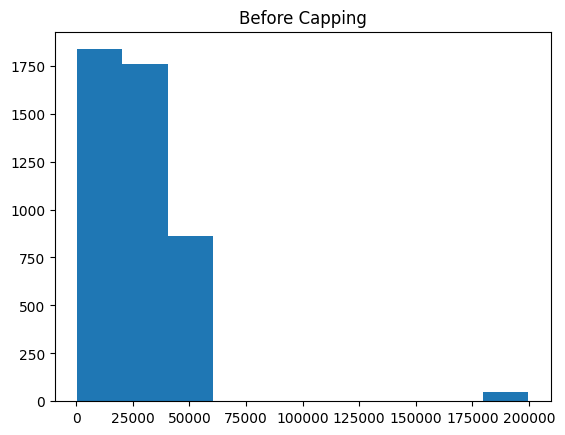

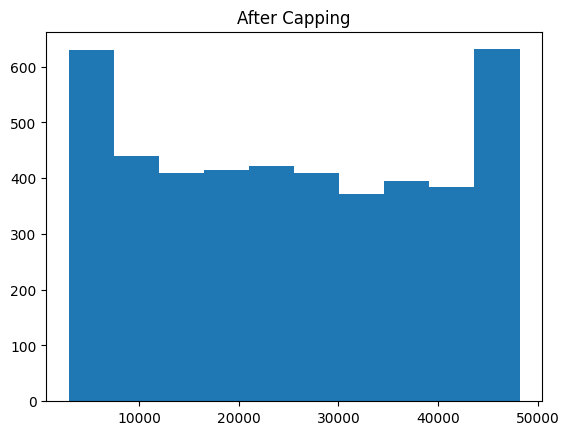

In [23]:
# Before
plt.figure()
plt.hist(df['Treatment_Cost'])
plt.title("Before Capping")
plt.show()

# Apply capping
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower_cap, upper_cap)

# After
plt.figure()
plt.hist(df['Treatment_Cost'])
plt.title("After Capping")
plt.show()

###Output Explanation
5th percentile and 95th percentile values are calculated
Extreme values below 5th percentile are replaced with lower cap
Extreme values above 95th percentile are replaced with upper cap
Updated Treatment_Cost values are displayed
###Conclusion

“Winsorization technique was applied to cap extreme values in the Treatment_Cost column. This helped in reducing the impact of outliers while retaining all records in the dataset.”

###Q8. Transformation (Log Transformation)


Apply log transformation on Treatment_Cost, create a new column, and compare before vs after distribution.

###Detailed Explanation

In many real-world datasets, numerical variables such as Treatment_Cost are highly skewed, meaning:

Most values are small
Few values are extremely large

This creates a right-skewed distribution, which can:

Affect statistical analysis
Reduce model accuracy
Make visualization difficult

 To solve this problem, we use log transformation.

🔹 What is Log Transformation?

Log transformation applies the logarithm function to data values:

It reduces the effect of large values
Makes the distribution more balanced
Converts skewed data into approximately normal distribution
🔹 Benefits:
Reduces skewness
Improves data symmetry
Makes analysis more reliable

A new column is created to store transformed values so that original data remains unchanged.

In [13]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Apply log transformation
df['Log_Treatment_Cost'] = np.log(df['Treatment_Cost'])

# Step 2: Show comparison
print("Before Transformation:")
print(df['Treatment_Cost'].head())

print("\nAfter Log Transformation:")
print(df['Log_Treatment_Cost'].head())

Before Transformation:
0    41010.0
1    12194.0
2    45086.0
3    40842.0
4     9873.0
Name: Treatment_Cost, dtype: float64

After Log Transformation:
0    10.621571
1     9.408699
2    10.716327
3    10.617466
4     9.197559
Name: Log_Treatment_Cost, dtype: float64


###Visualization Code

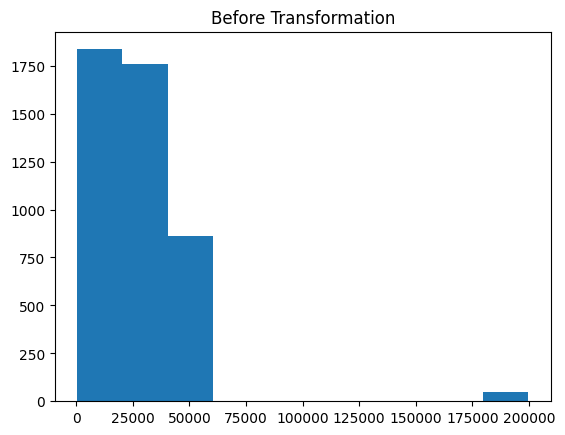

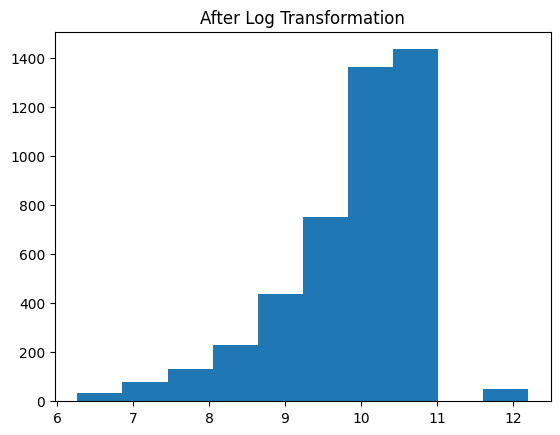

In [14]:
import matplotlib.pyplot as plt

# Before
plt.hist(df['Treatment_Cost'])
plt.title("Before Transformation")
plt.show()

# After
plt.hist(df['Log_Treatment_Cost'])
plt.title("After Log Transformation")
plt.show()

###Output Explanation
Original Treatment_Cost values are displayed
Log-transformed values are calculated and stored in a new column
The transformed data shows reduced skewness
Distribution becomes more balanced compared to original data
###Conclusion

“Log transformation was applied to reduce skewness in the Treatment_Cost column. This improved the distribution of data and made it more suitable for analysis.”

###Q9. Time-Based Missing Handling


Sort data by Admission_Date and apply forward fill or backward fill where appropriate. Justify your choice.

###Detailed Explanation

In time-based datasets, the sequence of data is very important. In a healthcare dataset, patient records are recorded based on time (Admission_Date).

Missing values in such datasets can be handled using time-based techniques.

🔹 Steps involved:
Convert Admission_Date into datetime format
Sort the dataset in chronological order
Fill missing values using:
Forward Fill (ffill)
Backward Fill (bfill)
🔹 Forward Fill vs Backward Fill:
Forward Fill (ffill):
Replaces missing values using the previous available value
Backward Fill (bfill):
Replaces missing values using the next available value
🔹 Choice of Method:

Forward Fill is preferred because:

Medical data follows a time sequence
Previous patient records influence future records
It maintains logical consistency

In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Step 1: Convert to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Step 2: Sort data
df = df.sort_values(by='Admission_Date')

# Step 3: Check missing values before
print("Missing values before:")
print(df.isnull().sum())

# Step 4: Apply forward fill
df = df.fillna(method='ffill')

# Step 5: Check missing values after
print("\nMissing values after:")
print(df.isnull().sum())

# Step 6: Display updated data
print("\nUpdated Data:")
print(df.head())

Missing values before:
Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

Missing values after:
Patient_ID            0
Age                   0
Gender                0
City                  0
Diagnosis             0
Hospital_Visits       0
Treatment_Cost        0
Insurance_Coverage    0
Admission_Date        0
dtype: int64

Updated Data:
      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
2702       17230  41.0    Male  Bangalore  Hypertension               18   
2624       16450  57.0  Female    Chennai      Diabetes               15   
1791       14612  94.0    Male      Delhi  Hypertension               14   
4292       12430  25.0    Male    Chennai      Diabetes               11   
2642       19262  25.0  Female  Hyderabad        Asthma                9   

      

/tmp/ipykernel_8943/1599822583.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


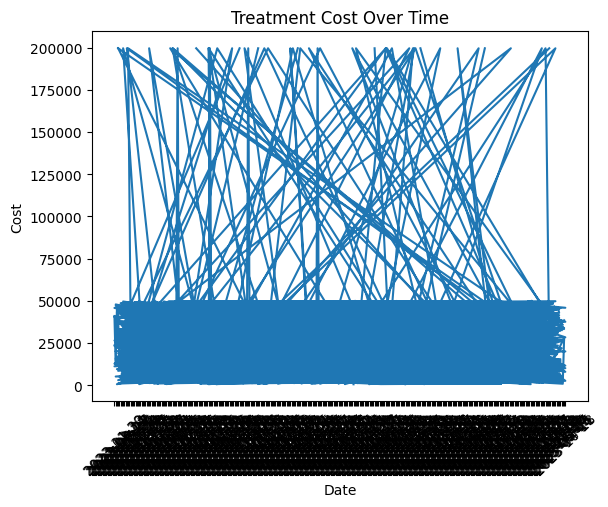

In [22]:
plt.figure()
plt.plot(df['Admission_Date'], df['Treatment_Cost'])
plt.title("Treatment Cost Over Time")
plt.xlabel("Date")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.show()

###Output Explanation
Admission_Date column is converted into datetime format
Dataset is sorted in chronological order
Missing values before filling are displayed
Forward fill method is applied
Missing values are reduced or removed
Updated dataset is displayed
###Conclusion
“The dataset was sorted based on Admission_Date and missing values were handled using forward fill method. This ensures logical consistency in time-based data and improves data quality.”